# VLM Model Response Evaluation via Gemini

**A robust, pipeline for evaluating Visual Language Model (VLM) outputs
using Gemini as a judge — with automatic API key rotation, configurable models, retry logic, and full logging.**

### Pipeline Features
| Feature | Details |
|---|---|
| **Multi-key rotation** | Pool of API keys — auto-rotates on quota/auth errors |
| **Configurable model** | Change `GEMINI_MODEL` in config to use any Gemini variant |
| **JSON retry** | Multiple parse strategies + configurable retries on parse failure |
| **Rate limiting** | Per-request interval with adaptive backoff |
| **Full logging** | Key switches, failures, retries all logged to file + console |
| **Score validation** | Range check (0–100), median/std statistics alongside mean |
| **Comparison** | Side-by-side pre vs post fine-tune summary |

> **Usage:** Edit `CONFIG` in *Cell 2*, then *Kernel → Restart & Run All*.


In [ ]:
# ── Install required packages (uncomment on fresh environment) ──────────────
#!pip install -q google-generativeai pillow tqdm

## ⚙️ Configuration

Edit this cell only. Everything downstream reads from `CONFIG`.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                        MASTER CONFIGURATION                              ║
# ║              Edit here, then Kernel → Restart & Run All                  ║
# ╚══════════════════════════════════════════════════════════════════════════╝

CONFIG = {

    # ── Gemini API Keys ───────────────────────────────────────────────────────
    # Add as many keys as you have. The engine tries them in order and
    # rotates to the next on quota / auth / rate-limit errors.
    "API_KEYS": [
        {"label": "faysalahmmed4200@gmail.com",    "key": "hidden"},
        {"label": "account2@gmail.com",    "key": "YOUR_API_KEY_2"},
        {"label": "account3@gmail.com",    "key": "YOUR_API_KEY_3"},
        {"label": "account4@gmail.com",    "key": "YOUR_API_KEY_4"},
    ],

    # ── Gemini Model ──────────────────────────────────────────────────────────
    "GEMINI_MODEL": "gemini-3.1-pro-preview",

    # ── Input files ───────────────────────────────────────────────────────────
    # Each entry defines one evaluation run.
    # "label"     : human-readable name shown in reports and saved filenames
    # "pkl_path"  : path to .pkl file containing list of dicts with keys:
    #               image (PIL.Image), prompt (str), model_response (str), true_response (str)
    # "output_json": path to save scored results
    "EVAL_RUNS": [
        {
            "label"       : "Pre-Finetune",
            "pkl_path"    : "pre_finetune_eval_predictions.pkl",
            "output_json" : "pre_finetune_gemini_scores.json",
        },
        {
            "label"       : "Post-Finetune",
            "pkl_path"    : "finetune_eval_predictions.pkl",
            "output_json" : "finetune_gemini_scores.json",
        },
    ],

    # ── Rate limiting ─────────────────────────────────────────────────────────
    # Seconds to wait between requests (per key).
    "REQUEST_INTERVAL_SEC"   : 5,

    # ── Retry settings ────────────────────────────────────────────────────────
    # Max retries when JSON parsing fails (Gemini returned malformed output).
    "JSON_PARSE_MAX_RETRIES" : 3,
    # Max retries on API call errors before rotating to next key.
    "API_MAX_RETRIES"        : 2,
    # Backoff multiplier on API errors (seconds).
    "BACKOFF_BASE_SEC"       : 5,

    # ── Logging ──────────────────────────────────────────────────────────────
    "LOG_FILE": "gemini_eval.log",

    # ── Evaluation prompt template ────────────────────────────────────────────
    # Available placeholders: {user_prompt}, {model_response}, {true_response}
    "EVAL_PROMPT_TEMPLATE": (
        "You are an expert evaluator for medical AI systems.\n"
        "Given:\n"
        "- The image (attached)\n"
        "- User Prompt: \"{user_prompt}\"\n"
        "- Model Response: \"{model_response}\"\n"
        "- Correct / Expected Response: \"{true_response}\"\n\n"
        "Evaluate how accurate, detailed, and faithful the model's response is to the expected one.\n"
        "Return output STRICTLY as valid JSON with no extra text, no markdown fences:\n"
        "{{\n"
        "  \"score\": <integer 0-100>,\n"
        "  \"explanation\": \"<brief reasoning under 60 words>\"\n"
        "}}"
    ),
}


In [3]:
# ── Imports ──────────────────────────────────────────────────────────────────
import base64
import json
import logging
import pickle
import re
import sys
import time
from io import BytesIO
from pathlib import Path
from typing import Any

import google.generativeai as genai
from PIL import Image
from tqdm import tqdm
import numpy as np


/opt/miniconda3/envs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/n9/z74ndvz95nn7gy9yw8d4zb0r0000gn/T/ipykernel_25720/2287046184.py:13: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [4]:
# ════════════════════════════════════════════════════════════════════════════
# LOGGING SETUP
# Logs to both console (INFO) and file (DEBUG) simultaneously.
# ════════════════════════════════════════════════════════════════════════════

def setup_logger(log_file: str) -> logging.Logger:
    """
    Create and return a logger that writes to console and to `log_file`.

    Parameters
    ----------
    log_file : path to the log file

    Returns
    -------
    logging.Logger
    """
    logger = logging.getLogger("GeminiEval")
    logger.setLevel(logging.DEBUG)
    logger.handlers.clear()                         # avoid duplicate handlers on re-run

    fmt = logging.Formatter(
        "%(asctime)s  [%(levelname)-8s]  %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    # Console handler — INFO and above
    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(logging.INFO)
    ch.setFormatter(fmt)
    logger.addHandler(ch)

    # File handler — DEBUG and above (captures everything including retries)
    fh = logging.FileHandler(log_file, mode="a", encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    return logger


LOGGER = setup_logger(CONFIG["LOG_FILE"])
LOGGER.info("Logger initialised.  Log file: %s", CONFIG["LOG_FILE"])


2026-04-30 23:55:06  [INFO    ]  Logger initialised.  Log file: gemini_eval.log


In [5]:
# ════════════════════════════════════════════════════════════════════════════
# API KEY MANAGER
# Maintains a pool of Gemini API keys and rotates on errors.
# ════════════════════════════════════════════════════════════════════════════

class APIKeyManager:
    """
    Round-robin API key pool with automatic rotation.

    Rotation is triggered when the caller reports an error string that
    matches one of the known quota / auth / rate-limit patterns.

    Attributes
    ----------
    current_index : int  —  index of the currently active key
    usage_counts  : list[int]  —  requests served per key
    error_counts  : list[int]  —  errors per key
    rotation_log  : list[dict]  —  timestamped rotation events
    """

    # Error substrings that should trigger key rotation
    ROTATE_ON: tuple[str, ...] = (
        "quota",
        "rate",
        "resource_exhausted",
        "429",
        "403",
        "unauthorized",
        "permission_denied",
        "api_key",
        "invalid api",
    )

    def __init__(self, key_configs: list[dict]):
        """
        Parameters
        ----------
        key_configs : list of dicts with 'label' and 'key' fields
        """
        if not key_configs:
            raise ValueError("At least one API key must be provided.")

        self.keys          = [k["key"]   for k in key_configs]
        self.labels        = [k["label"] for k in key_configs]
        self.current_index = 0
        self.usage_counts  = [0] * len(self.keys)
        self.error_counts  = [0] * len(self.keys)
        self.rotation_log: list[dict] = []

        self._configure_current()
        LOGGER.info(
            "APIKeyManager initialised with %d key(s).  Active: %s",
            len(self.keys), self.current_label,
        )

    # ── Properties ────────────────────────────────────────────────────────────
    @property
    def current_key(self) -> str:
        return self.keys[self.current_index]

    @property
    def current_label(self) -> str:
        return self.labels[self.current_index]

    # ── Internal helpers ──────────────────────────────────────────────────────
    def _configure_current(self) -> None:
        """Call genai.configure() with the currently active key."""
        genai.configure(api_key=self.current_key)

    def _should_rotate(self, error_msg: str) -> bool:
        """Return True if the error message indicates a rotatable failure."""
        lo = error_msg.lower()
        return any(pat in lo for pat in self.ROTATE_ON)

    # ── Public API ────────────────────────────────────────────────────────────
    def record_success(self) -> None:
        """Increment usage counter for the current key."""
        self.usage_counts[self.current_index] += 1

    def record_error(self, error_msg: str) -> bool:
        """
        Record an error for the current key and rotate if warranted.

        Parameters
        ----------
        error_msg : string representation of the exception

        Returns
        -------
        bool : True if rotation occurred, False otherwise
        """
        self.error_counts[self.current_index] += 1
        LOGGER.warning(
            "Error on key '%s': %s", self.current_label, error_msg[:200]
        )

        if self._should_rotate(error_msg) and len(self.keys) > 1:
            return self.rotate()
        return False

    def rotate(self) -> bool:
        """
        Advance to the next key in the pool (wraps around).

        Returns
        -------
        bool : True if a different key is now active, False if only one key exists
        """
        if len(self.keys) == 1:
            LOGGER.warning("Only one API key available — cannot rotate.")
            return False

        old_label = self.current_label
        old_index = self.current_index
        self.current_index = (self.current_index + 1) % len(self.keys)
        self._configure_current()

        event = {
            "timestamp"  : time.strftime("%Y-%m-%d %H:%M:%S"),
            "from_label" : old_label,
            "from_index" : old_index,
            "to_label"   : self.current_label,
            "to_index"   : self.current_index,
        }
        self.rotation_log.append(event)
        LOGGER.info(
            "🔄 API key rotated: '%s' → '%s'",
            old_label, self.current_label,
        )
        return True

    def summary(self) -> None:
        """Print a usage / error summary for all keys."""
        print("\n" + "═" * 55)
        print("  API Key Usage Summary")
        print("═" * 55)
        for i, label in enumerate(self.labels):
            active = " ← active" if i == self.current_index else ""
            print(
                f"  [{i}] {label[:40]:40s}  "
                f"used={self.usage_counts[i]:>4}  "
                f"errors={self.error_counts[i]:>3}{active}"
            )
        print(f"  Total rotations : {len(self.rotation_log)}")
        print("═" * 55)


# ── Instantiate the key manager ──────────────────────────────────────────────
KEY_MANAGER = APIKeyManager(CONFIG["API_KEYS"])


2026-04-30 23:55:06  [INFO    ]  APIKeyManager initialised with 4 key(s).  Active: faysalahmmed4200@gmail.com


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# IMAGE UTILITIES
# ════════════════════════════════════════════════════════════════════════════

def pil_to_bytes(pil_img: Image.Image, fmt: str = "JPEG") -> bytes:
    """
    Encode a PIL Image to raw bytes in the given format.

    Parameters
    ----------
    pil_img : PIL.Image.Image
    fmt     : target format ('JPEG' or 'PNG').
              'JPG' is normalised to 'JPEG'.

    Returns
    -------
    bytes  —  raw encoded image bytes
    """
    fmt = (fmt or pil_img.format or "PNG").upper()
    if fmt == "JPG":
        fmt = "JPEG"

    buffer = BytesIO()
    # JPEG does not support alpha; convert if needed
    if fmt == "JPEG" and pil_img.mode in ("RGBA", "P"):
        pil_img = pil_img.convert("RGB")
    pil_img.save(buffer, format=fmt)
    return buffer.getvalue()


In [7]:
# ════════════════════════════════════════════════════════════════════════════
# JSON PARSING UTILITIES
# Multiple extraction strategies applied in order of preference.
# ════════════════════════════════════════════════════════════════════════════

def _strip_markdown_fences(text: str) -> str:
    """Remove ```json ... ``` or ``` ... ``` fences from text."""
    text = re.sub(r"```(?:json)?\s*", "", text)
    text = re.sub(r"```", "", text)
    return text.strip()


def _extract_json_strategies(raw: str) -> dict | None:
    """
    Try multiple strategies to extract a JSON object from raw text.

    Strategy order:
      1. Direct parse of stripped text
      2. Strip markdown fences, then parse
      3. Regex extraction of first {...} block (greedy, multi-line)
      4. Regex extraction with non-greedy inner match
      5. Manual key extraction as last resort

    Parameters
    ----------
    raw : raw string returned by Gemini

    Returns
    -------
    dict if any strategy succeeds, None otherwise
    """
    cleaned = raw.strip()

    # Strategy 1: direct parse
    try:
        return json.loads(cleaned)
    except json.JSONDecodeError:
        pass

    # Strategy 2: strip markdown fences
    try:
        return json.loads(_strip_markdown_fences(cleaned))
    except json.JSONDecodeError:
        pass

    # Strategy 3: greedy {...} extraction
    match = re.search(r"\{.*\}", cleaned, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except json.JSONDecodeError:
            pass

    # Strategy 4: non-greedy extraction
    match = re.search(r"\{.*?\}", cleaned, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except json.JSONDecodeError:
            pass

    # Strategy 5: manual key extraction (fallback)
    score_match = re.search(r'["\'"]?score["\'"]?\s*:\s*(\d+)', cleaned, re.IGNORECASE)
    expl_match  = re.search(r'["\'"]?explanation["\'"]?\s*:\s*["\'"]([^"\'",]+)', cleaned, re.IGNORECASE)
    if score_match:
        score = int(score_match.group(1))
        expl  = expl_match.group(1).strip() if expl_match else "Extracted via fallback."
        LOGGER.debug("JSON extracted via manual key search.")
        return {"score": score, "explanation": expl}

    return None


def validate_score(score: Any) -> int | None:
    """
    Validate and coerce a score value to int in [0, 100].

    Parameters
    ----------
    score : raw score value from parsed JSON

    Returns
    -------
    int in [0, 100] or None if invalid
    """
    if score is None:
        return None
    try:
        s = int(float(score))
        if 0 <= s <= 100:
            return s
        LOGGER.warning("Score %d is outside [0, 100] — clamping.", s)
        return max(0, min(100, s))         # clamp rather than discard
    except (ValueError, TypeError):
        LOGGER.warning("Could not convert score '%s' to int.", score)
        return None


def parse_gemini_response(raw: str) -> dict:
    """
    Parse a Gemini judge response into {'score': int|None, 'explanation': str}.

    Applies extraction strategies and validates the score range.

    Parameters
    ----------
    raw : raw text from Gemini response

    Returns
    -------
    dict with keys 'score' (int or None) and 'explanation' (str)
    """
    parsed = _extract_json_strategies(raw)

    if parsed is None:
        LOGGER.warning("All JSON extraction strategies failed.  Raw: %s", raw[:200])
        return {"score": None, "explanation": raw}

    score = validate_score(parsed.get("score"))
    expl  = str(parsed.get("explanation", "No explanation provided.")).strip()

    return {"score": score, "explanation": expl}


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# GEMINI CALLER
# Handles API retries, key rotation, and JSON parse retries.
# ════════════════════════════════════════════════════════════════════════════

def call_gemini_with_retry(
    image_bytes:   bytes,
    eval_prompt:   str,
    model_name:    str,
    key_manager:   APIKeyManager,
    api_retries:   int = 2,
    parse_retries: int = 3,
    backoff_base:  float = 5.0,
) -> dict:
    """
    Call the Gemini API with automatic key rotation and JSON parse retries.

    Retry strategy
    --------------
    1. On API error (quota / auth / rate-limit): rotate key and retry up to
       `api_retries` times.  Non-rotatable errors are re-raised immediately.
    2. On JSON parse failure: resend the same prompt up to `parse_retries`
       times with an explicit repair instruction appended.

    Parameters
    ----------
    image_bytes   : raw JPEG/PNG bytes to send as the image part
    eval_prompt   : text evaluation prompt
    model_name    : Gemini model identifier string
    key_manager   : APIKeyManager instance
    api_retries   : max retries on API-level errors
    parse_retries : max retries when Gemini returns unparseable JSON
    backoff_base  : initial wait (seconds) before first retry; doubles each attempt

    Returns
    -------
    dict  with keys 'score' (int|None) and 'explanation' (str)
    """

    def _build_model() -> genai.GenerativeModel:
        """Instantiate model (always uses the currently active key)."""
        return genai.GenerativeModel(model_name)

    def _api_call(prompt_text: str) -> str:
        """Make one API call; return raw response text."""
        m        = _build_model()
        response = m.generate_content([
            {"mime_type": "image/jpeg", "data": image_bytes},
            {"text": prompt_text},
        ])
        return response.text.strip()

    current_prompt = eval_prompt

    for api_attempt in range(api_retries + 1):

        try:
            raw = _api_call(current_prompt)
            key_manager.record_success()

        except Exception as exc:
            err_str = str(exc)
            rotated = key_manager.record_error(err_str)

            if api_attempt < api_retries:
                wait = backoff_base * (2 ** api_attempt)
                LOGGER.warning(
                    "API error (attempt %d/%d), waiting %.0fs before retry. %s",
                    api_attempt + 1, api_retries + 1, wait, err_str[:150],
                )
                time.sleep(wait)
                continue                 # retry with (possibly new) key
            else:
                # Exhausted all API retries
                LOGGER.error("API call failed after %d retries: %s", api_retries + 1, err_str[:300])
                return {"score": None, "explanation": f"API error: {err_str[:200]}"}

        # ── API call succeeded; now try to parse JSON ─────────────────────────
        for parse_attempt in range(parse_retries + 1):

            result = parse_gemini_response(raw)

            if result["score"] is not None:
                if parse_attempt > 0:
                    LOGGER.debug(
                        "JSON parsed successfully on parse attempt %d.", parse_attempt + 1
                    )
                return result

            # Score is None — JSON parsing failed
            if parse_attempt < parse_retries:
                LOGGER.warning(
                    "JSON parse failed (attempt %d/%d). Retrying with repair prompt.",
                    parse_attempt + 1, parse_retries + 1,
                )
                # Append a repair instruction and call Gemini again
                repair_suffix = (
                    "\n\n[IMPORTANT] Your previous response could not be parsed as JSON. "
                    "Reply ONLY with a valid JSON object — no markdown, no extra text:\n"
                    '{"score": <integer 0-100>, "explanation": "<under 60 words>"}'
                )
                try:
                    raw = _api_call(eval_prompt + repair_suffix)
                    key_manager.record_success()
                except Exception as exc2:
                    LOGGER.warning("Repair API call failed: %s", str(exc2)[:150])
                    break              # give up on parse retries, return None score
            else:
                LOGGER.error(
                    "JSON parse failed after %d retries.  Storing raw text.",
                    parse_retries + 1,
                )

        # Return with score=None if all parse retries exhausted
        return {"score": None, "explanation": raw[:500]}

    # Should never reach here
    return {"score": None, "explanation": "Unexpected failure."}


In [9]:
# ════════════════════════════════════════════════════════════════════════════
# STATISTICS UTILITIES
# ════════════════════════════════════════════════════════════════════════════

def compute_statistics(scored_results: list[dict], label: str) -> dict:
    """
    Compute and print descriptive statistics for a list of scored results.

    Parameters
    ----------
    scored_results : list of dicts, each containing a 'gemini_feedback' key
                     which itself has a 'score' key (int or None)
    label          : display name for this run (e.g. 'Pre-Finetune')

    Returns
    -------
    dict with keys: label, n_total, n_valid, n_failed,
                    mean, median, std, min, max, percentile_25, percentile_75
    """
    valid_scores = [
        d["gemini_feedback"]["score"]
        for d in scored_results
        if isinstance(d["gemini_feedback"].get("score"), (int, float))
    ]

    n_total = len(scored_results)
    n_valid = len(valid_scores)
    n_failed = n_total - n_valid

    if n_valid == 0:
        LOGGER.warning("No valid scores found for '%s'.", label)
        stats = {
            "label": label, "n_total": n_total, "n_valid": 0, "n_failed": n_failed,
            "mean": None, "median": None, "std": None,
            "min": None, "max": None, "percentile_25": None, "percentile_75": None,
        }
    else:
        arr = np.array(valid_scores, dtype=float)
        stats = {
            "label"        : label,
            "n_total"      : n_total,
            "n_valid"      : n_valid,
            "n_failed"     : n_failed,
            "mean"         : float(np.mean(arr)),
            "median"       : float(np.median(arr)),
            "std"          : float(np.std(arr)),
            "min"          : float(np.min(arr)),
            "max"          : float(np.max(arr)),
            "percentile_25": float(np.percentile(arr, 25)),
            "percentile_75": float(np.percentile(arr, 75)),
        }

    # Pretty print
    print(f"\n{'═'*50}")
    print(f"  Gemini Evaluation Results — {label}")
    print(f"{'═'*50}")
    print(f"  Total samples    : {n_total}")
    print(f"  Valid scores     : {n_valid}  (failed/skipped: {n_failed})")
    if n_valid > 0:
        print(f"  Mean score       : {stats['mean']:.2f} / 100")
        print(f"  Median score     : {stats['median']:.2f} / 100")
        print(f"  Std deviation    : {stats['std']:.2f}")
        print(f"  Min / Max        : {stats['min']:.0f} / {stats['max']:.0f}")
        print(f"  IQR (25–75)      : {stats['percentile_25']:.1f} – {stats['percentile_75']:.1f}")
    print(f"{'═'*50}")

    return stats


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# EVALUATION RUNNER
# Orchestrates the full scoring loop for one .pkl file.
# ════════════════════════════════════════════════════════════════════════════

def run_evaluation(
    pkl_path:         str,
    output_json_path: str,
    label:            str,
    config:           dict,
    key_manager:      APIKeyManager,
) -> tuple[list[dict], dict]:
    """
    Load predictions from a .pkl file and score each with Gemini.

    Each item in the pkl must be a dict with keys:
      - image         : PIL.Image.Image
      - prompt        : str  (the user's original question)
      - model_response: str  (the VLM's answer to evaluate)
      - true_response : str  (the ground-truth / expected answer)

    Parameters
    ----------
    pkl_path         : path to input .pkl file
    output_json_path : path to write scored JSON results
    label            : display name for this run
    config           : master CONFIG dict
    key_manager      : shared APIKeyManager instance

    Returns
    -------
    scored_results : list of dicts (one per sample)
    stats          : statistics dict from compute_statistics()
    """
    # ── Load predictions ──────────────────────────────────────────────────────
    pkl_path_obj = Path(pkl_path)
    if not pkl_path_obj.exists():
        LOGGER.error("pkl file not found: %s", pkl_path)
        raise FileNotFoundError(f"pkl file not found: {pkl_path}")

    with open(pkl_path_obj, "rb") as f:
        examples = pickle.load(f)

    LOGGER.info("Loaded %d samples from '%s' for run: %s", len(examples), pkl_path, label)
    print(f"\n{'─'*60}")
    print(f"  Starting evaluation run: {label}")
    print(f"  Samples     : {len(examples)}")
    print(f"  Model       : {config['GEMINI_MODEL']}")
    print(f"  Output file : {output_json_path}")
    print(f"{'─'*60}")

    scored_results = []
    request_interval = config["REQUEST_INTERVAL_SEC"]

    for i, ex in enumerate(tqdm(examples, desc=f"Scoring [{label}]")):
        loop_start = time.time()

        # ── Validate required keys ────────────────────────────────────────────
        for required_key in ("image", "prompt", "model_response", "true_response"):
            if required_key not in ex:
                LOGGER.error(
                    "Sample %d missing key '%s' — skipping.", i, required_key
                )
                scored_results.append({
                    "index"         : i,
                    "prompt"        : ex.get("prompt", ""),
                    "model_response": ex.get("model_response", ""),
                    "true_response" : ex.get("true_response", ""),
                    "gemini_feedback": {
                        "score"      : None,
                        "explanation": f"Missing required key: {required_key}",
                    },
                })
                continue

        # ── Prepare image bytes ───────────────────────────────────────────────
        try:
            image_bytes = pil_to_bytes(ex["image"], fmt="JPEG")
        except Exception as img_err:
            LOGGER.error("Image encoding failed for sample %d: %s", i, img_err)
            scored_results.append({
                "index"         : i,
                "prompt"        : ex["prompt"],
                "model_response": ex["model_response"],
                "true_response" : ex["true_response"],
                "gemini_feedback": {"score": None, "explanation": f"Image error: {img_err}"},
            })
            continue

        # ── Build evaluation prompt ───────────────────────────────────────────
        eval_prompt = config["EVAL_PROMPT_TEMPLATE"].format(
            user_prompt    =ex["prompt"],
            model_response =ex["model_response"],
            true_response  =ex["true_response"],
        )

        # ── Call Gemini ───────────────────────────────────────────────────────
        feedback = call_gemini_with_retry(
            image_bytes   =image_bytes,
            eval_prompt   =eval_prompt,
            model_name    =config["GEMINI_MODEL"],
            key_manager   =key_manager,
            api_retries   =config["API_MAX_RETRIES"],
            parse_retries =config["JSON_PARSE_MAX_RETRIES"],
            backoff_base  =config["BACKOFF_BASE_SEC"],
        )

        scored_results.append({
            "index"          : i,
            "prompt"         : ex["prompt"],
            "model_response" : ex["model_response"],
            "true_response"  : ex["true_response"],
            "gemini_feedback": feedback,
        })

        LOGGER.debug(
            "Sample %d scored: %s  (key: %s)",
            i, feedback["score"], key_manager.current_label,
        )

        # ── Rate limiting: sleep the remaining time in this request window ────
        elapsed = time.time() - loop_start
        sleep_time = max(0.0, request_interval - elapsed)
        if sleep_time > 0:
            time.sleep(sleep_time)

    # ── Compute and display statistics ────────────────────────────────────────
    stats = compute_statistics(scored_results, label)

    # ── Save results to JSON ──────────────────────────────────────────────────
    with open(output_json_path, "w", encoding="utf-8") as out_f:
        json.dump(scored_results, out_f, indent=4, ensure_ascii=False)
    LOGGER.info("Results saved to '%s'", output_json_path)
    print(f"\n  ✔ Results saved: {output_json_path}")

    return scored_results, stats


In [11]:
# ════════════════════════════════════════════════════════════════════════════
# RUN ALL EVALUATION RUNS  (defined in CONFIG['EVAL_RUNS'])
# ════════════════════════════════════════════════════════════════════════════

all_results: dict[str, list[dict]] = {}   # label → scored results
all_stats:   dict[str, dict]       = {}   # label → stats dict

for run_cfg in CONFIG["EVAL_RUNS"]:
    label      = run_cfg["label"]
    pkl_path   = run_cfg["pkl_path"]
    out_json   = run_cfg["output_json"]

    LOGGER.info("="*60)
    LOGGER.info("Starting run: %s", label)
    LOGGER.info("="*60)

    results, stats = run_evaluation(
        pkl_path         = pkl_path,
        output_json_path = out_json,
        label            = label,
        config           = CONFIG,
        key_manager      = KEY_MANAGER,
    )

    all_results[label] = results
    all_stats[label]   = stats

print("\n\nAll evaluation runs complete.")
KEY_MANAGER.summary()


2026-04-30 23:02:27  [INFO    ]  ============================================================
2026-04-30 23:02:27  [INFO    ]  Starting run: Pre-Finetune
2026-04-30 23:02:27  [INFO    ]  ============================================================
2026-04-30 23:02:27  [INFO    ]  Loaded 35 samples from 'pre_finetune_eval_predictions.pkl' for run: Pre-Finetune

────────────────────────────────────────────────────────────
  Starting evaluation run: Pre-Finetune
  Samples     : 35
  Model       : gemini-3.1-pro-preview
  Output file : pre_finetune_gemini_scores.json
────────────────────────────────────────────────────────────


Scoring [Pre-Finetune]: 100%|██████████| 35/35 [23:04<00:00, 39.55s/it]  


══════════════════════════════════════════════════
  Gemini Evaluation Results — Pre-Finetune
══════════════════════════════════════════════════
  Total samples    : 35
  Valid scores     : 35  (failed/skipped: 0)
  Mean score       : 62.14 / 100
  Median score     : 60.00 / 100
  Std deviation    : 13.22
  Min / Max        : 30 / 85
  IQR (25–75)      : 60.0 – 75.0
══════════════════════════════════════════════════
2026-04-30 23:25:31  [INFO    ]  Results saved to 'pre_finetune_gemini_scores.json'

  ✔ Results saved: pre_finetune_gemini_scores.json
2026-04-30 23:25:31  [INFO    ]  ============================================================
2026-04-30 23:25:31  [INFO    ]  Starting run: Post-Finetune
2026-04-30 23:25:31  [INFO    ]  ============================================================
2026-04-30 23:25:31  [INFO    ]  Loaded 35 samples from 'finetune_eval_predictions.pkl' for run: Post-Finetune



────────────────────────────────────────────────────────────
  Starting evaluation run: Post-Finetune
  Samples     : 35
  Model       : gemini-3.1-pro-preview
  Output file : finetune_gemini_scores.json
────────────────────────────────────────────────────────────


Scoring [Post-Finetune]: 100%|██████████| 35/35 [13:51<00:00, 23.75s/it]


══════════════════════════════════════════════════
  Gemini Evaluation Results — Post-Finetune
══════════════════════════════════════════════════
  Total samples    : 35
  Valid scores     : 35  (failed/skipped: 0)
  Mean score       : 87.86 / 100
  Median score     : 90.00 / 100
  Std deviation    : 11.79
  Min / Max        : 30 / 95
  IQR (25–75)      : 90.0 – 92.5
══════════════════════════════════════════════════
2026-04-30 23:39:23  [INFO    ]  Results saved to 'finetune_gemini_scores.json'

  ✔ Results saved: finetune_gemini_scores.json


All evaluation runs complete.

═══════════════════════════════════════════════════════
  API Key Usage Summary
═══════════════════════════════════════════════════════
  [0] faysalahmmed4200@gmail.com                used=  70  errors=  0 ← active
  [1] account2@gmail.com                        used=   0  errors=  0
  [2] account3@gmail.com                        used=   0  errors=  0
  [3] account4@gmail.com                        used=   0  err

In [20]:
# ════════════════════════════════════════════════════════════════════════════
# COMPARISON TABLE  (all runs side by side)
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd

def build_comparison_table(stats_dict: dict[str, dict]) -> pd.DataFrame:
    """
    Build and display a comparison DataFrame from all run statistics.

    Parameters
    ----------
    stats_dict : mapping of run-label → stats dict

    Returns
    -------
    pd.DataFrame  (also prints and saves to CSV)
    """
    rows = []
    metric_keys = [
        ("n_total",       "Total Samples"),
        ("n_valid",       "Valid Scores"),
        ("n_failed",      "Failed / Skipped"),
        ("mean",          "Mean Score"),
        ("median",        "Median Score"),
        ("std",           "Std Deviation"),
        ("min",           "Min Score"),
        ("max",           "Max Score"),
        ("percentile_25", "25th Percentile"),
        ("percentile_75", "75th Percentile"),
    ]

    for key, display_name in metric_keys:
        row = {"Metric": display_name}
        for label, stats in stats_dict.items():
            val = stats.get(key)
            if val is None:
                row[label] = "N/A"
            elif isinstance(val, float):
                row[label] = f"{val:.2f}"
            else:
                row[label] = str(val)
        rows.append(row)

    df = pd.DataFrame(rows).set_index("Metric")

    print("\n" + "═"*65)
    print("  EVALUATION COMPARISON TABLE")
    print("═"*65)
    print(df.to_string())
    print("═"*65)

    # Save
    csv_path = "gemini_eval_comparison.csv"
    df.to_csv(csv_path)
    print(f"\n  Comparison table saved: {csv_path}")
    return df


comparison_df = build_comparison_table(all_stats)



═════════════════════════════════════════════════════════════════
  EVALUATION COMPARISON TABLE
═════════════════════════════════════════════════════════════════
                 Pre-Finetune Post-Finetune
Metric                                     
Total Samples              35            35
Valid Scores               35            35
Failed / Skipped            0             0
Mean Score              62.14         87.86
Median Score            60.00         90.00
Std Deviation           13.22         11.79
Min Score               30.00         30.00
Max Score               85.00         95.00
25th Percentile         60.00         90.00
75th Percentile         75.00         92.50
═════════════════════════════════════════════════════════════════

  Comparison table saved: gemini_eval_comparison.csv


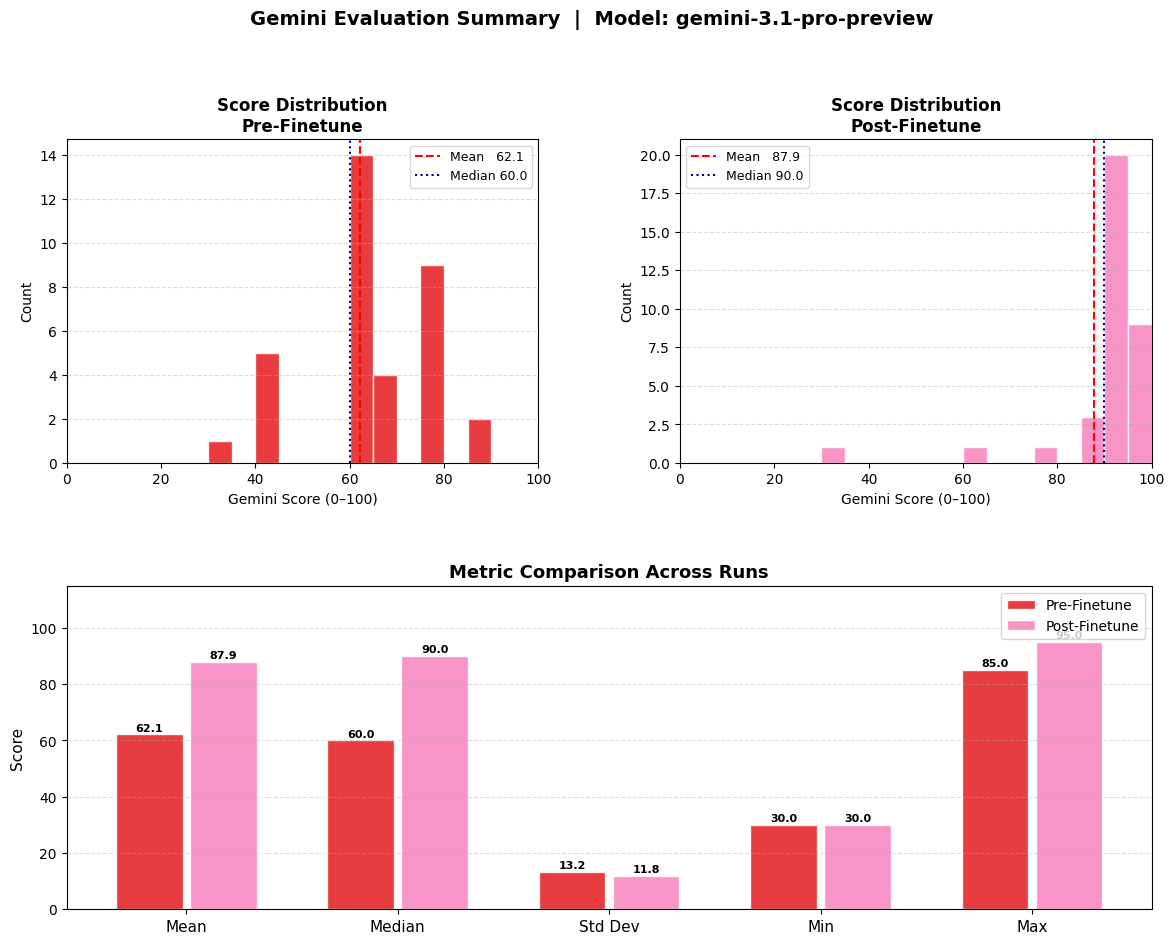

Figure saved: gemini_eval_distributions.png


In [12]:
# ════════════════════════════════════════════════════════════════════════════
# VISUALISATION  —  Score distributions & comparison bar chart
# ════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_score_distributions(
    all_results: dict[str, list[dict]],
    all_stats:   dict[str, dict],
    save_path:   str = "gemini_eval_distributions.png",
) -> None:
    """
    Plot score histograms + KDE for each run and a grouped bar comparison.

    Parameters
    ----------
    all_results : label → list of scored dicts
    all_stats   : label → stats dict
    save_path   : path to save the combined figure
    """
    n_runs = len(all_results)
    colors = plt.cm.Set1(np.linspace(0, 0.8, n_runs))
    labels = list(all_results.keys())

    fig = plt.figure(figsize=(7 * n_runs, 10))
    gs  = fig.add_gridspec(2, n_runs, hspace=0.38, wspace=0.30)

    # ── Row 0: histograms per run ─────────────────────────────────────────────
    for col, (label, color) in enumerate(zip(labels, colors)):
        ax = fig.add_subplot(gs[0, col])
        valid = [
            d["gemini_feedback"]["score"]
            for d in all_results[label]
            if isinstance(d["gemini_feedback"].get("score"), (int, float))
        ]
        if valid:
            ax.hist(valid, bins=20, range=(0, 100), color=color,
                    edgecolor="white", alpha=0.85)
            s = all_stats[label]
            ax.axvline(s["mean"],   color="red",   linestyle="--", linewidth=1.5,
                       label=f"Mean   {s['mean']:.1f}")
            ax.axvline(s["median"], color="navy",  linestyle=":",  linewidth=1.5,
                       label=f"Median {s['median']:.1f}")
            ax.legend(fontsize=9)
        ax.set_xlim(0, 100)
        ax.set_title(f"Score Distribution\n{label}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Gemini Score (0–100)", fontsize=10)
        ax.set_ylabel("Count", fontsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    # ── Row 1: grouped comparison bar chart ───────────────────────────────────
    ax2 = fig.add_subplot(gs[1, :])
    metric_names = ["Mean", "Median", "Std Dev", "Min", "Max"]
    metric_keys  = ["mean", "median", "std", "min", "max"]
    x = np.arange(len(metric_names))
    bar_w = 0.7 / max(n_runs, 1)

    for i, (label, color) in enumerate(zip(labels, colors)):
        s = all_stats[label]
        vals = [
            s[k] if s[k] is not None else 0.0
            for k in metric_keys
        ]
        offset = (i - (n_runs - 1) / 2) * bar_w
        bars = ax2.bar(x + offset, vals, bar_w * 0.9, color=color,
                       alpha=0.85, edgecolor="white", label=label)
        for bar, val in zip(bars, vals):
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{val:.1f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold",
            )

    ax2.set_xticks(x)
    ax2.set_xticklabels(metric_names, fontsize=11)
    ax2.set_ylabel("Score", fontsize=11)
    ax2.set_title("Metric Comparison Across Runs", fontsize=13, fontweight="bold")
    ax2.legend(fontsize=10)
    ax2.grid(axis="y", linestyle="--", alpha=0.4)
    ax2.set_ylim(0, 115)

    plt.suptitle(
        f"Gemini Evaluation Summary  |  Model: {CONFIG['GEMINI_MODEL']}",
        fontsize=14, fontweight="bold", y=1.01,
    )
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure saved: {save_path}")


plot_score_distributions(all_results, all_stats)


In [13]:
# ════════════════════════════════════════════════════════════════════════════
# PER-SAMPLE INSPECTOR
# Pretty-print individual scored results for manual inspection.
# ════════════════════════════════════════════════════════════════════════════

def inspect_samples(
    scored_results: list[dict],
    label:          str,
    n:              int = 5,
    sort_by:        str = "score",          # 'score' | 'index'
    ascending:      bool = True,
) -> None:
    """
    Print the first `n` samples sorted by score or index.

    Parameters
    ----------
    scored_results : list of scored dicts
    label          : run label for display header
    n              : number of samples to show
    sort_by        : 'score' to sort by Gemini score, 'index' for original order
    ascending      : sort direction
    """
    if sort_by == "score":
        valid = [d for d in scored_results if d["gemini_feedback"].get("score") is not None]
        ordered = sorted(valid, key=lambda d: d["gemini_feedback"]["score"], reverse=not ascending)
    else:
        ordered = sorted(scored_results, key=lambda d: d.get("index", 0), reverse=not ascending)

    print(f"\n{'═'*70}")
    print(f"  {label}  —  top {min(n, len(ordered))} samples (sort: {sort_by}, asc={ascending})")
    print(f"{'═'*70}")

    for i, item in enumerate(ordered[:n]):
        fb = item["gemini_feedback"]
        print(f"\n  [{i+1}] Index: {item.get('index', '?')}  |  Score: {fb.get('score', 'N/A')}/100")
        print(f"       Prompt        : {item['prompt'][:100]}")
        print(f"       Model Response: {item['model_response'][:120]}")
        print(f"       True Response : {item['true_response'][:120]}")
        print(f"       Explanation   : {fb.get('explanation', '')[:200]}")

    print()


# ── Example: show 5 lowest-scoring Pre-Finetune samples ─────────────────────
if CONFIG["EVAL_RUNS"]:
    first_label = CONFIG["EVAL_RUNS"][0]["label"]
    if first_label in all_results:
        inspect_samples(
            all_results[first_label],
            label     = first_label,
            n         = 5,
            sort_by   = "score",
            ascending = True,   # lowest scores first
        )



══════════════════════════════════════════════════════════════════════
  Pre-Finetune  —  top 5 samples (sort: score, asc=True)
══════════════════════════════════════════════════════════════════════

  [1] Index: 26  |  Score: 30/100
       Prompt        : You are an AI assistant specialized in model interpretability. I am providing:
- CNN model Grad-CAM+
       Model Response: The model focused on the central region of the image, likely highlighting the area of interest for the diagnosis of beni
       True Response : The model focused on the lesion's irregular, dark brown, waxy surface and subtle keratin inclusions, consistent with the
       Explanation   : The model's response is overly generic and fails to identify the specific visual features (texture, horn cysts) required for the classification. It lacks the clinical detail of the expected response.

  [2] Index: 2  |  Score: 40/100
       Prompt        : You are an AI assistant specialized in model interpretability. I am provi